# Script to plot Figure 1

## Preamble

### Load packages required

In [1]:
#SJL 1/2020

import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

import csv

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
#from matplotlib.mlab import griddata
from scipy.interpolate import griddata

from scipy import interpolate

#plotting packages
import matplotlib as mpl
# mpl.use('PDF')
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec

cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")
    
#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')

# #add Tex fonts
# if sys.platform== 'darwin':
#     os.environ["PATH"] += os.pathsep + '/Library/TeX/texbin'

/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

### Define constants to normalize axes etc.

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

### Set parameters and select bodies to plot

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
#info for HERCULES arrays
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#angular momentum to plot
AM_plot=np.asarray([2.70, 2.0, 0.82, 0.42, 0.18])
Nplot=np.size(AM_plot)

#colors to plot
col=[0.9,0.59,0.42,0.2,0.0]


## Main script

### Load in HERCULES planetary structure database

In [4]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

########################################################################################
#read in the database

Hdatabase=HERCULES_random_planet_database_1D()
Hdatabase.make_array(Hdir,Hname)
Hdatabase.initialize_interpolation([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],\
                                   [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],0], flag_extrap=1)

#extract the latitudes for each Mu point
Nmu=Hdatabase.parr[0].Nmu
lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi


Earth_correct_params_S3.20c
	 Earth_correct_params_S3.20c_AM3.3125
	 Earth_correct_params_S3.20c_AM3.30625
	 Earth_correct_params_S3.20c_AM3.325


### Calculate the surface shape for each of the selected AM

In [5]:
#now run through all AM and calculate the radius of the surface
print('begin')

rsurf=np.zeros((np.size(AM_plot),Nmu))

for i in np.arange(np.size(AM_plot)):
    temp_data=Hdatabase.interp_database(AM_plot[i]*LEM,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                       [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)

    rsurf[i,:]=np.asarray(temp_data[17])
    
print('end')

begin
end


In [6]:
#now run through all AM steps and calculate the radius of the surface
print('begin')

AM_plot2=np.linspace(0.0,3.2,1000)

amax=np.zeros(np.size(AM_plot2))
bmax=np.zeros(np.size(AM_plot2))

for i in np.arange(np.size(AM_plot2)):
    temp_data=Hdatabase.interp_database(AM_plot2[i]*LEM,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                       [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)

    amax[i]=np.asarray(temp_data[17])[0]
    bmax[i]=np.asarray(temp_data[17])[-1]
    
print('end')

begin
end


### Construct the figure

/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_99451/1110496043.py:42: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax1_twin.plot(AM_plot2,(amax-bmax)/1E6,'k-', linewidth=1.5,color=color_twin)
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_99451/1110496043.py:45: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax1in_twin.plot(AM_plot2,(amax-bmax)/1E6,'k-', linewidth=1.5,color=color_twin)
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_99451/1110496043.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


done


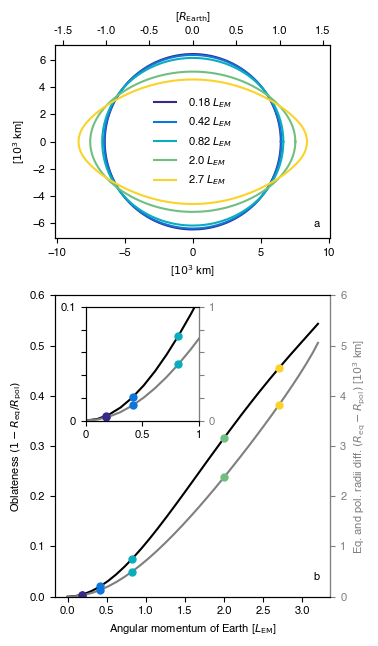

In [7]:
#figure with an added panel for difference between 

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure1.pdf')
mpl.pyplot.close(fig)

#
#initialise the actual figure
fig = plt.figure(figsize=(3.9,6.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])

#twin axes
ax_twiny=ax.twiny()
ax1_twin=ax1.twinx()

#subplot for low-AM zoom in
ax1in = fig.add_axes([.245, .35, .29, .175])#, facecolor='w')
ax1in_twin=ax1in.twinx()

#select fonts
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)

color_twin=cm.binary(0.5)

ax1.plot(AM_plot2,(1-(bmax/amax)),'k-', linewidth=1.5)
ax1_twin.plot(AM_plot2,(amax-bmax)/1E6,'k-', linewidth=1.5,color=color_twin)

ax1in.plot(AM_plot2,(1-(bmax/amax)),'k-', linewidth=1.5)
ax1in_twin.plot(AM_plot2,(amax-bmax)/1E6,'k-', linewidth=1.5,color=color_twin)

#Loop over and plot each AM 
for i in np.flipud(np.arange(np.size(AM_plot))):
    #append arrays to make a continuous 360deg shape
    x=np.append(rsurf[i,:]*np.sin(np.arccos(Hdatabase.parr[0].mu)), \
                                  np.append(-np.flipud(rsurf[i,:]*np.sin(np.arccos(Hdatabase.parr[0].mu))),\
                                 np.append(-rsurf[i,:]*np.sin(np.arccos(Hdatabase.parr[0].mu)),\
                                 np.flipud(rsurf[i,:]*np.sin(np.arccos(Hdatabase.parr[0].mu))))))/1E6
    
    z=np.append(rsurf[i,:]*Hdatabase.parr[0].mu, \
                               np.append(np.flipud(rsurf[i,:]*Hdatabase.parr[0].mu),\
                                         np.append(-rsurf[i,:]*Hdatabase.parr[0].mu,\
                                                   np.flipud(-rsurf[i,:]*Hdatabase.parr[0].mu))))/1E6
    
    ax.plot(x,z,\
            '-', color=cmaps.parula(col[i]), linewidth=1.5, label=r" "+str(AM_plot[i])+" $L_{EM}$")
    
    ax1.plot(AM_plot[i],(1-rsurf[i,-1]/rsurf[i,0]),'.',color=cmaps.parula(col[i]),markersize=10)
    ax1_twin.plot(AM_plot[i],(rsurf[i,0]-rsurf[i,-1])/1E6,'.',color=cmaps.parula(col[i]),markersize=10)
    
    ax1in.plot(AM_plot[i],(1-rsurf[i,-1]/rsurf[i,0]),'.',color=cmaps.parula(col[i]),markersize=10)
    ax1in_twin.plot(AM_plot[i],(rsurf[i,0]-rsurf[i,-1])/1E6,'.',color=cmaps.parula(col[i]),markersize=10)

    
#ax.set_aspect('equal', 'box')
ax.set_aspect('equal', adjustable='datalim')
ax_twiny.set_aspect('equal', adjustable='datalim')

ax.legend(frameon=False)

ax1_twin.set_ylim([0,6.0])
ax1.set_ylim([0,0.6])

ax1in.set_xlim([0,1.0])
ax1in_twin.set_xlim([0,1.0])

ax1in_twin.set_ylim([0,1.0])
ax1in.set_ylim([0,0.1])

ax1in.set_xticks(np.linspace(0,1,3))
ax1in_twin.set_yticks(np.linspace(0,1,6))
ax1in.set_yticks(np.linspace(0,0.1,6))

ax1in.set_xticklabels([0,0.5,1])
ax1in_twin.set_yticklabels([0,'','','','',1])
ax1in.set_yticklabels([0,'','','','',0.1])

ax.set_xlabel('[$10^3$ km]')
ax.set_ylabel('[$10^3$ km]')

xR_labels=np.asarray([-1.5,-1.0,-0.5,0,0.5,1.0,1.5])
ax_twiny.set_xticks(xR_labels*REarth/1E6)
ax_twiny.set_xticklabels(xR_labels)

ax_twiny.set_xlabel('[$R_\mathrm{Earth}$]')


ax1.set_xlabel(r'Angular momentum of Earth [$L_{\rm EM}$]')
ax1_twin.set_ylabel(r'Eq. and pol. radii diff. $(R_{\rm eq}-R_{\rm pol})$ [$10^3$ km]')
ax1.set_ylabel(r'Oblateness $(1-R_{\rm eq}/R_{\rm pol})$')

ax.text(0.96, 0.05, 'a', \
                       horizontalalignment='right',verticalalignment='bottom', fontsize=8,transform=ax.transAxes, color='k')
ax1.text(0.96, 0.05, 'b', \
                       horizontalalignment='right',verticalalignment='bottom', fontsize=8,transform=ax1.transAxes, color='k')

ax1_twin.spines['right'].set_color(color_twin)
ax1_twin.yaxis.label.set_color(color_twin)
ax1_twin.tick_params(axis='y', colors=color_twin)

ax1in_twin.spines['right'].set_color(color_twin)
ax1in_twin.yaxis.label.set_color(color_twin)
ax1in_twin.tick_params(axis='y', colors=color_twin)

fig.tight_layout()
plt.savefig('Figure1.pdf')

print('done')